# 人脸识别基础教程

本 Notebook 对应任务 2.1，目标是理解人脸识别系统的组成、验证与识别的区别，以及特征相似度和阈值的作用。

## 学习目标

完成本教程后，你应该能够：

- 说明人脸检测、关键点定位、对齐和识别分别解决什么问题；
- 区分人脸验证（1:1）和人脸识别（1:N）；
- 理解人脸特征向量（embedding）和余弦相似度；
- 解释阈值如何影响误接受率和误拒绝率；
- 描述一个完整人脸识别系统的基本流程。

## 1. 什么是人脸识别？

人脸识别不是单一算法，而是一条处理流水线：

```text
输入图像
   ↓
人脸检测（找到人脸框）
   ↓
关键点定位（找到眼睛、鼻子、嘴角）
   ↓
人脸对齐（校正旋转、尺度和位置）
   ↓
特征提取（生成 embedding）
   ↓
特征比较（计算相似度）
   ↓
验证或识别结果
```

每一步都会影响最终性能。例如，检测框不准确或人脸没有对齐，都会使同一个人的特征变得不稳定。

## 2. 流水线中的核心任务

| 任务 | 输入 | 输出 | 作用 |
|---|---|---|---|
| 人脸检测 | 一张图像 | 人脸边界框和置信度 | 判断人脸在哪里 |
| 关键点定位 | 人脸区域 | 眼睛、鼻子、嘴角等坐标 | 描述面部几何位置 |
| 人脸对齐 | 人脸图像与关键点 | 标准姿态的人脸图像 | 减少旋转和姿态差异 |
| 特征提取 | 对齐后的人脸 | 固定长度向量 | 用数字表示身份特征 |
| 特征比较 | 两个或多个向量 | 相似度和身份结果 | 完成验证或识别 |

### 检测不等于识别

- **检测**只回答“图中哪里有人脸”；
- **识别**回答“这张脸是谁”或“这两张脸是否属于同一个人”。

## 3. 人脸检测、关键点和对齐

人脸检测器通常输出边界框，有些模型还会同时输出关键点。RetinaFace 就是一种联合预测人脸框和面部关键点的单阶段检测方法。

常见的五点关键点包括：

1. 左眼中心；
2. 右眼中心；
3. 鼻尖；
4. 左嘴角；
5. 右嘴角。

对齐通常根据这些点估计仿射变换，把双眼和嘴角移动到统一位置。这样可以降低侧倾、旋转和尺度变化对特征的影响。

## 4. 人脸特征向量（Embedding）

深度模型不会直接把姓名写进图片，而是把一张人脸转换为固定长度的数值向量。例如：

```text
[0.12, -0.34, 0.88, ..., 0.05]
```

理想情况下：

- 同一个人的向量彼此接近；
- 不同人的向量彼此远离。

ArcFace 通过在角度空间加入 margin，使不同身份的特征更容易分离。实际系统常先对特征进行 L2 归一化，再计算余弦相似度。

## 5. 人脸验证与人脸识别

| 模式 | 问题 | 比较方式 | 示例 |
|---|---|---|---|
| 1:1 验证 | 两张脸是否为同一个人？ | 查询特征与一个注册特征比较 | 手机解锁 |
| 1:N 识别 | 查询脸属于数据库中的谁？ | 查询特征与整个特征库比较 | 相册人物分类 |

验证通常根据阈值输出“同一人/不同人”；识别通常先找相似度最高的候选人，再判断最高分是否达到阈值。

## 6. 用模拟特征理解余弦相似度

下面使用低维模拟向量讲解原理。真实模型常输出数百维特征，数值由神经网络生成。这里的模拟向量不能代表真实模型准确率。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

In [2]:
def l2_normalize(vector):
    vector = np.asarray(vector, dtype=float)
    norm = np.linalg.norm(vector)
    if norm == 0:
        raise ValueError("零向量不能归一化")
    return vector / norm


def cosine_similarity(vector_a, vector_b):
    return float(np.dot(l2_normalize(vector_a), l2_normalize(vector_b)))


person_a_photo_1 = np.array([0.80, 0.40, 0.30, 0.10])
person_a_photo_2 = np.array([0.78, 0.42, 0.28, 0.12])
person_b_photo = np.array([-0.20, 0.10, 0.80, 0.50])

same_score = cosine_similarity(person_a_photo_1, person_a_photo_2)
different_score = cosine_similarity(person_a_photo_1, person_b_photo)

print(f"同一个人的模拟相似度：{same_score:.3f}")
print(f"不同人的模拟相似度：{different_score:.3f}")

assert same_score > different_score

同一个人的模拟相似度：0.999
不同人的模拟相似度：0.185


余弦相似度范围是 `[-1, 1]`。越接近 1，方向越相似。是否属于同一个人仍需要通过验证集选择阈值，不能把示例中的阈值直接用于真实系统。

## 7. 1:1 人脸验证示例

In [3]:
def verify_faces(embedding_a, embedding_b, threshold=0.80):
    score = cosine_similarity(embedding_a, embedding_b)
    return score >= threshold, score


same_person, score = verify_faces(person_a_photo_1, person_a_photo_2)
print(f"A1 与 A2：相似度={score:.3f}，判断={'同一人' if same_person else '不同人'}")

same_person, score = verify_faces(person_a_photo_1, person_b_photo)
print(f"A1 与 B：相似度={score:.3f}，判断={'同一人' if same_person else '不同人'}")

assert verify_faces(person_a_photo_1, person_a_photo_2)[0]
assert not verify_faces(person_a_photo_1, person_b_photo)[0]

A1 与 A2：相似度=0.999，判断=同一人
A1 与 B：相似度=0.185，判断=不同人


## 8. 1:N 人脸识别示例

Gallery（注册库）保存每个身份的模板特征。查询时计算查询特征与所有模板的相似度，返回最高分候选人。

In [4]:
gallery = {
    "Alice": person_a_photo_1,
    "Bob": person_b_photo,
    "Carol": np.array([0.15, 0.85, -0.25, 0.40]),
}


def identify_face(query_embedding, gallery_embeddings, threshold=0.80):
    scores = {
        name: cosine_similarity(query_embedding, embedding)
        for name, embedding in gallery_embeddings.items()
    }
    best_name = max(scores, key=scores.get)
    best_score = scores[best_name]
    return (best_name if best_score >= threshold else "Unknown"), best_score, scores


identity, score, all_scores = identify_face(person_a_photo_2, gallery)
print("全部相似度：", {name: round(value, 3) for name, value in all_scores.items()})
print(f"识别结果：{identity}，最高相似度={score:.3f}")

assert identity == "Alice"

全部相似度： {'Alice': 0.999, 'Bob': 0.187, 'Carol': 0.491}
识别结果：Alice，最高相似度=0.999


## 9. 阈值、FAR 与 FRR

阈值不是越高越好，也不是越低越好：

- **FAR（False Accept Rate，误接受率）**：不同人被错误判断为同一个人的比例；
- **FRR（False Reject Rate，误拒绝率）**：同一个人被错误判断为不同人的比例；
- **TAR（True Accept Rate，正确接受率）**：`1 - FRR`；
- **TAR@FAR**：在指定 FAR 下报告 TAR，是人脸验证常用指标。

阈值升高通常会降低 FAR，但会提高 FRR。真实阈值必须在独立验证集上确定。

阈值：0.60
模拟 FAR：0.004
模拟 FRR：0.000


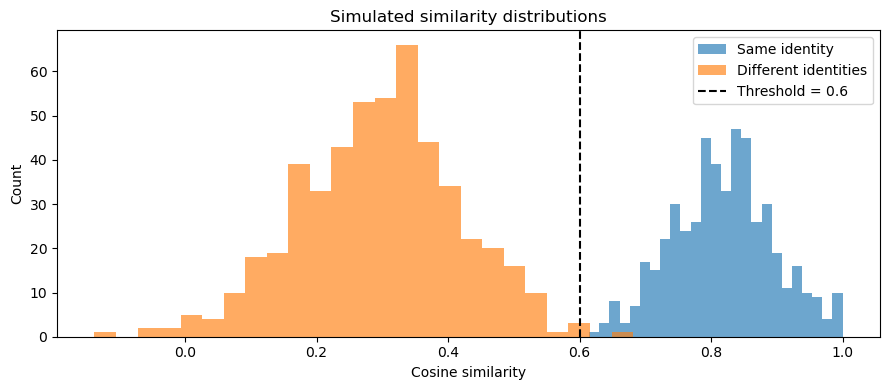

In [5]:
# 模拟两类相似度分布，仅用于解释阈值，不代表真实模型。
rng = np.random.default_rng(42)
genuine_scores = np.clip(rng.normal(0.82, 0.08, 500), -1, 1)
impostor_scores = np.clip(rng.normal(0.30, 0.12, 500), -1, 1)
threshold = 0.60

far = np.mean(impostor_scores >= threshold)
frr = np.mean(genuine_scores < threshold)

print(f"阈值：{threshold:.2f}")
print(f"模拟 FAR：{far:.3f}")
print(f"模拟 FRR：{frr:.3f}")

plt.figure(figsize=(9, 4))
plt.hist(genuine_scores, bins=25, alpha=0.65, label="Same identity")
plt.hist(impostor_scores, bins=25, alpha=0.65, label="Different identities")
plt.axvline(threshold, color="black", linestyle="--", label=f"Threshold = {threshold}")
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.title("Simulated similarity distributions")
plt.legend()
plt.tight_layout()
plt.show()

assert 0 <= far <= 1 and 0 <= frr <= 1

## 10. 常见评估方式

### 验证任务

1. 准备同一人和不同人的图片对；
2. 提取每张图片的人脸特征；
3. 计算每对特征的相似度；
4. 在训练集之外选择阈值；
5. 报告 Accuracy、ROC、FAR、FRR 或 TAR@FAR。

LFW 是经典的非受控场景人脸验证数据集。比较结果时必须遵循相同的数据划分和评估协议。

### 识别任务

常见指标包括 Rank-1 准确率、Top-k 准确率，以及在开放集条件下的误识率。

## 11. 真实场景中的主要难点

- **姿态变化**：正脸和侧脸差异较大；
- **光照变化**：逆光、阴影和过曝会改变外观；
- **遮挡**：口罩、眼镜、头发会遮住关键区域；
- **图像质量**：低分辨率、运动模糊和压缩影响特征；
- **年龄变化**：跨年龄图片可能有明显差异；
- **数据偏差**：不同群体的数据不均衡可能造成性能差异；
- **活体攻击**：照片、视频或面具可能欺骗系统。

## 12. 隐私、伦理与安全

人脸特征属于敏感生物识别信息。实际项目应：

- 获得合法授权和明确同意；
- 只收集完成任务所需的数据；
- 对原图和特征向量进行访问控制与加密；
- 设置保存期限和删除机制；
- 分群体评估误差，检查潜在偏差；
- 不把课堂示例直接用于高风险身份决策。

## 13. 小练习

1. 将验证阈值从 `0.80` 改为 `0.95`，观察判断结果；
2. 修改模拟分布中的均值或标准差，观察 FAR 和 FRR；
3. 向 Gallery 添加一个新身份，再运行 1:N 识别；
4. 用自己的话解释为什么检测成功不代表识别一定成功。

## 14. 总结

- 人脸识别系统由检测、关键点、对齐、特征提取和特征比较组成；
- 1:1 验证判断两张脸是否同一人，1:N 识别从 Gallery 中搜索身份；
- Embedding 是人脸的数值表示，余弦相似度可用于比较特征；
- 阈值控制 FAR 与 FRR 的权衡，必须基于验证数据确定；
- 真实系统还需要考虑数据质量、偏差、隐私和安全。

## 参考资料

1. Deng et al., [ArcFace: Additive Angular Margin Loss for Deep Face Recognition](https://openaccess.thecvf.com/content_CVPR_2019/html/Deng_ArcFace_Additive_Angular_Margin_Loss_for_Deep_Face_Recognition_CVPR_2019_paper.html), CVPR 2019.
2. Deng et al., [RetinaFace: Single-Shot Multi-Level Face Localisation in the Wild](https://openaccess.thecvf.com/content_CVPR_2020/papers/Deng_RetinaFace_Single-Shot_Multi-Level_Face_Localisation_in_the_Wild_CVPR_2020_paper.pdf), CVPR 2020.
3. Huang and Learned-Miller, [Labeled Faces in the Wild: Updates and New Reporting Procedures](https://web.cs.umass.edu/publication/docs/2014/UM-CS-2014-003.pdf), UMass Amherst, 2014.
4. NIST, [Face Technology Evaluations: FRTE/FATE](https://www.nist.gov/programs-projects/face-technology-evaluations-frtefate).